In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')

# Tier 2 선수 데이터
bae = pd.read_csv('../data/bae_statcast.csv')
choi = pd.read_csv('../data/choi_statcast.csv')

# player list
players = pd.read_csv('../data/player_list.csv')

print(f"배지환: {len(bae)} 타석 데이터 (2022-2025)")
print(f"최지만: {len(choi)} 타석 데이터 (2016-2023)")
print("봉중근: Statcast 이전 시대 (2002-2004) — 시즌 요약만 분석")

배지환: 2478 타석 데이터 (2022-2025)
최지만: 9006 타석 데이터 (2016-2023)
봉중근: Statcast 이전 시대 (2002-2004) — 시즌 요약만 분석


/var/folders/sc/x7fdp9gs2b3fbn2n56ssf8f40000gn/T/ipykernel_3069/201765405.py:9: DtypeWarning: Columns (42) have mixed types. Specify dtype option on import or set low_memory=False.
  choi = pd.read_csv('../data/choi_statcast.csv')


In [2]:
# 배지환 시즌별 분석
bae['season'] = pd.to_datetime(bae['game_date']).dt.year
bae_clean = bae.dropna(subset=['launch_speed'])

bae_by_season = bae_clean.groupby('season').agg(
    plate_appearances=('game_date', 'count'),
    avg_exit_velo=('launch_speed', 'mean'),
    avg_launch_angle=('launch_angle', 'mean')
).round(1)

print("=== 배지환 시즌별 Statcast 요약 ===")
print(bae_by_season)

=== 배지환 시즌별 Statcast 요약 ===
        plate_appearances  avg_exit_velo  avg_launch_angle
season                                                    
2022                   48           77.0               9.1
2023                  569           80.4              13.1
2024                  113           81.2              15.0
2025                   72           80.5              15.9


In [3]:
# 최지만 시즌별 분석
choi['season'] = pd.to_datetime(choi['game_date']).dt.year
choi_clean = choi.dropna(subset=['launch_speed'])

choi_by_season = choi_clean.groupby('season').agg(
    plate_appearances=('game_date', 'count'),
    avg_exit_velo=('launch_speed', 'mean'),
    avg_launch_angle=('launch_angle', 'mean')
).round(1)

print("=== 최지만 시즌별 Statcast 요약 ===")
print(choi_by_season)

=== 최지만 시즌별 Statcast 요약 ===
        plate_appearances  avg_exit_velo  avg_launch_angle
season                                                    
2016                  126           85.1              15.9
2017                   14           91.0               7.1
2018                  221           85.9              17.1
2019                  527           85.4              16.8
2020                  211           85.4              16.0
2021                  362           83.7              16.2
2022                  500           84.5              17.1
2023                  189           84.2              17.9


/var/folders/sc/x7fdp9gs2b3fbn2n56ssf8f40000gn/T/ipykernel_3069/3910948309.py:2: DtypeWarning: Columns (85,86) have mixed types. Specify dtype option on import or set low_memory=False.
  choo = pd.read_csv('../data/choo_statcast.csv')


차트 저장 완료!


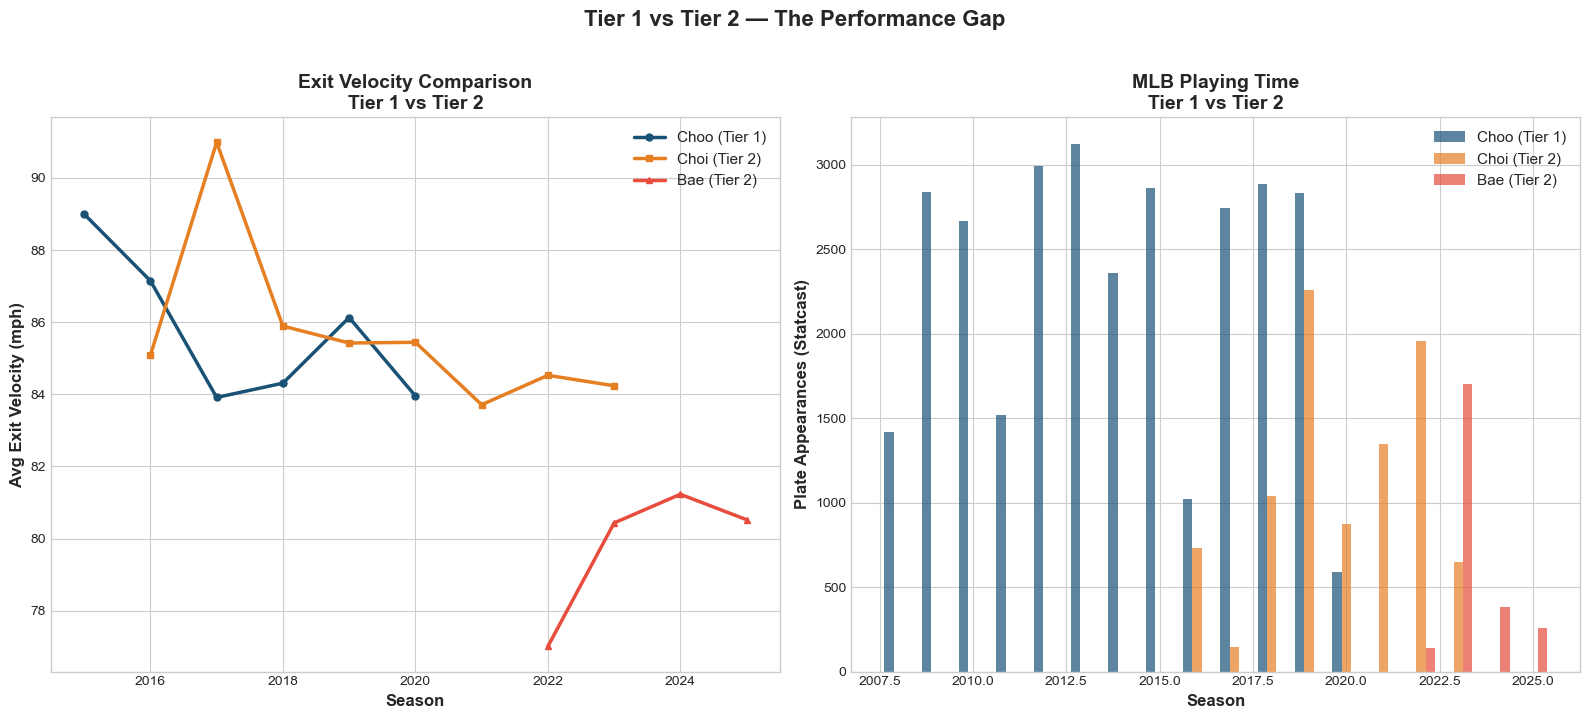

In [4]:
# 추신수 데이터도 불러오기 (비교용)
choo = pd.read_csv('../data/choo_statcast.csv')
choo['season'] = pd.to_datetime(choo['game_date']).dt.year
choo_clean = choo.dropna(subset=['launch_speed'])
choo_by_season = choo_clean.groupby('season')['launch_speed'].mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 좌: Exit Velocity 시즌별 비교
ax1 = axes[0]
ax1.plot(choo_by_season.index, choo_by_season.values, 
         color='#1a5276', linewidth=2.5, marker='o', markersize=5,
         label='Choo (Tier 1)')

choi_velo = choi_clean.groupby('season')['launch_speed'].mean()
ax1.plot(choi_velo.index, choi_velo.values,
         color='#e67e22', linewidth=2.5, marker='s', markersize=5,
         label='Choi (Tier 2)')

bae_velo = bae_clean.groupby('season')['launch_speed'].mean()
ax1.plot(bae_velo.index, bae_velo.values,
         color='#e74c3c', linewidth=2.5, marker='^', markersize=5,
         label='Bae (Tier 2)')

ax1.set_xlabel('Season', fontsize=12, fontweight='bold')
ax1.set_ylabel('Avg Exit Velocity (mph)', fontsize=12, fontweight='bold')
ax1.set_title('Exit Velocity Comparison\nTier 1 vs Tier 2', 
              fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)

# 우: 타석 수 비교 (MLB 출장 기회의 차이)
ax2 = axes[1]

# 시즌별 타석 수
choo_pa = choo.groupby('season')['game_date'].count()
choi_pa = choi.groupby('season')['game_date'].count()
bae_pa = bae.groupby('season')['game_date'].count()

ax2.bar([x - 0.25 for x in choo_pa.index], choo_pa.values, 
        width=0.25, color='#1a5276', alpha=0.7, label='Choo (Tier 1)')
ax2.bar(list(choi_pa.index), choi_pa.values,
        width=0.25, color='#e67e22', alpha=0.7, label='Choi (Tier 2)')
ax2.bar([x + 0.25 for x in bae_pa.index], bae_pa.values,
        width=0.25, color='#e74c3c', alpha=0.7, label='Bae (Tier 2)')

ax2.set_xlabel('Season', fontsize=12, fontweight='bold')
ax2.set_ylabel('Plate Appearances (Statcast)', fontsize=12, fontweight='bold')
ax2.set_title('MLB Playing Time\nTier 1 vs Tier 2', 
              fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)

plt.suptitle('Tier 1 vs Tier 2 — The Performance Gap', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../visualizations/07_tier1_vs_tier2_comparison.png', dpi=150, bbox_inches='tight')
print("차트 저장 완료!")
plt.show()

차트 저장 완료!


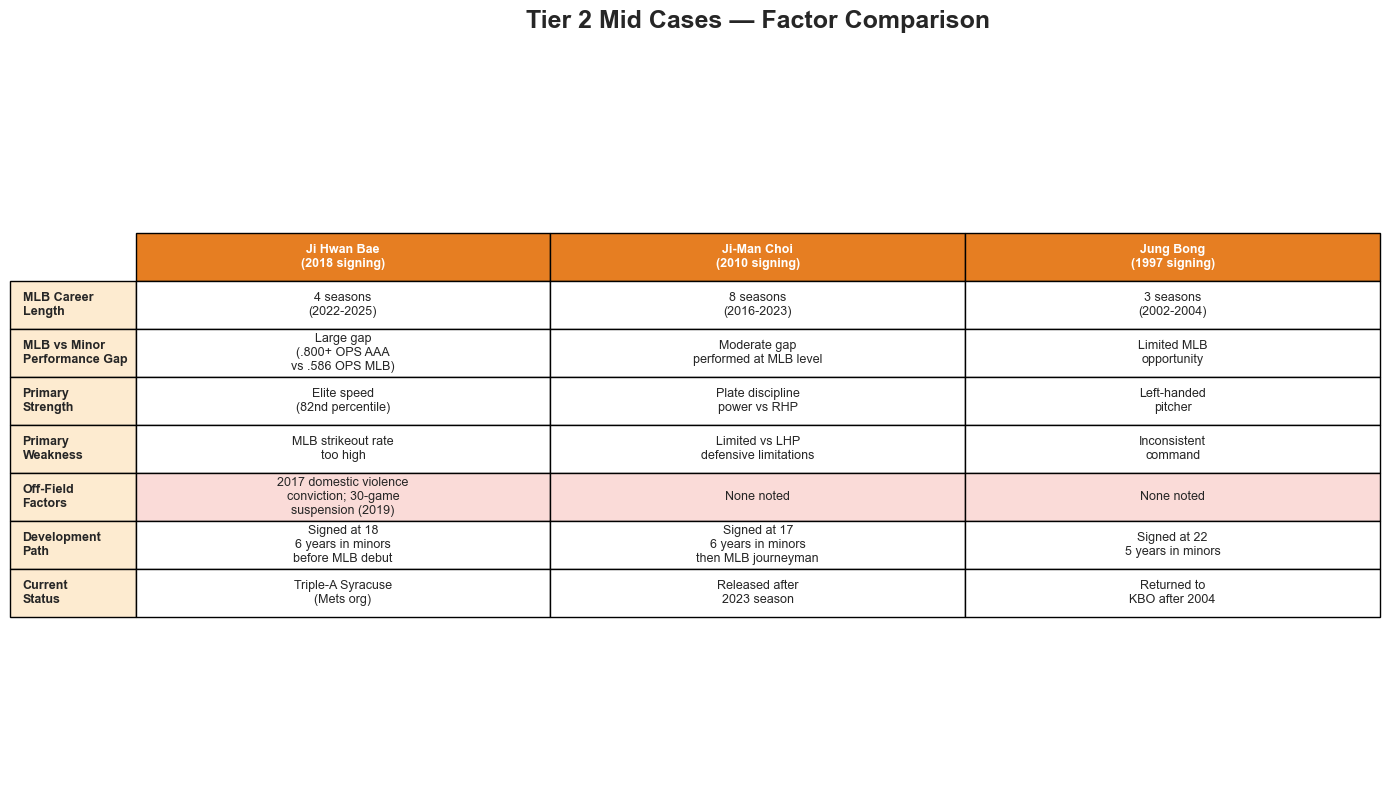

In [5]:
fig, ax = plt.subplots(figsize=(14, 8))

factors = {
    'Factor': [
        'MLB Career\nLength',
        'MLB vs Minor\nPerformance Gap',
        'Primary\nStrength',
        'Primary\nWeakness',
        'Off-Field\nFactors',
        'Development\nPath',
        'Current\nStatus'
    ],
    'Ji Hwan Bae': [
        '4 seasons\n(2022-2025)',
        'Large gap\n(.800+ OPS AAA\nvs .586 OPS MLB)',
        'Elite speed\n(82nd percentile)',
        'MLB strikeout rate\ntoo high',
        '2017 domestic violence\nconviction; 30-game\nsuspension (2019)',
        'Signed at 18\n6 years in minors\nbefore MLB debut',
        'Triple-A Syracuse\n(Mets org)'
    ],
    'Ji-Man Choi': [
        '8 seasons\n(2016-2023)',
        'Moderate gap\nperformed at MLB level',
        'Plate discipline\npower vs RHP',
        'Limited vs LHP\ndefensive limitations',
        'None noted',
        'Signed at 17\n6 years in minors\nthen MLB journeyman',
        'Released after\n2023 season'
    ],
    'Jung Bong': [
        '3 seasons\n(2002-2004)',
        'Limited MLB\nopportunity',
        'Left-handed\npitcher',
        'Inconsistent\ncommand',
        'None noted',
        'Signed at 22\n5 years in minors',
        'Returned to\nKBO after 2004'
    ]
}

cell_text = []
for i in range(len(factors['Factor'])):
    cell_text.append([
        factors['Ji Hwan Bae'][i],
        factors['Ji-Man Choi'][i],
        factors['Jung Bong'][i]
    ])

table = ax.table(
    cellText=cell_text,
    rowLabels=factors['Factor'],
    colLabels=['Ji Hwan Bae\n(2018 signing)', 'Ji-Man Choi\n(2010 signing)', 'Jung Bong\n(1997 signing)'],
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2.5)

# 헤더 색상
for j in range(3):
    table[0, j].set_facecolor('#e67e22')
    table[0, j].set_text_props(color='white', fontweight='bold')

# 행 라벨 색상
for i in range(len(factors['Factor'])):
    table[i + 1, -1].set_facecolor('#fdebd0')
    table[i + 1, -1].set_text_props(fontweight='bold')

# Off-field row 강조 (5번째 행, index 4+1=5)
for j in range(3):
    table[5, j].set_facecolor('#fadbd8')

ax.axis('off')
ax.set_title('Tier 2 Mid Cases — Factor Comparison', 
             fontsize=18, fontweight='bold', pad=30)

plt.tight_layout()
plt.savefig('../visualizations/08_tier2_factor_comparison.png', dpi=150, bbox_inches='tight')
print("차트 저장 완료!")
plt.show()

## Tier 2 Analysis: Why They Didn't Reach Tier 1

### Ji Hwan Bae — The "Four-A Player" Problem
- Consistently dominant in Triple-A (.800+ OPS) but unable to translate 
  to MLB (.586 OPS in 163 career games).
- Elite speed (82nd percentile sprint speed) is a genuine MLB tool, 
  but bat-to-ball issues at the MLB level limited his impact.
- Off-field factor: A 2017 domestic violence conviction resulted in a 
  30-game minor league suspension in 2019. While this occurred early in 
  his career, it is a relevant data point in his development trajectory.
- **Lesson for Moon:** Raw tools alone do not guarantee MLB success. 
  The ability to make adjustments against MLB-level pitching is critical.

### Ji-Man Choi — The Journeyman Path
- Most successful Tier 2 player with 8 MLB seasons across 6 organizations.
- Found a niche as a platoon first baseman effective against right-handed pitching.
- Career was limited by defensive limitations and inability to hit left-handed pitching.
- **Lesson for Moon:** Even without becoming a star, a long MLB career is 
  possible by identifying and maximizing a specific skill niche.

### Jung Bong — The Early Exit
- Shortest MLB career of all players studied (3 seasons).
- Left-handed pitching was his primary asset, but inconsistent command 
  prevented sustained MLB opportunity.
- Returned to KBO, where he had a productive career.
- **Lesson for Moon:** The path back to KBO is always available, but 
  maximizing the MLB opportunity window requires rapid adaptation.

### Common Tier 2 Pattern
- All three players spent 5-6 years in the minor leagues before MLB.
- The MLB vs minor league performance gap was the defining characteristic.
- None developed a truly elite MLB-level skill that could sustain a 
  long career the way Tier 1 players did.